In [15]:
# CNN - CIFAR-10 Image Classification
# https://www.researchgate.net/publication/323026933/figure/fig2/AS:591960742043648@1518145847527/Some-labeled-and-unlabeled-images-of-CIFAR-10-after-Stage-1.png

# https://www.theclickreader.com/wp-content/uploads/2020/08/color-channels-RGB.jpg

# https://media.geeksforgeeks.org/wp-content/uploads/20230329095332/RGB-arrays-combined-to-make-image.jpg

# https://miro.medium.com/v2/resize:fit:1296/1*8zHs6CWVv_ljVQEEZ71fNQ.png

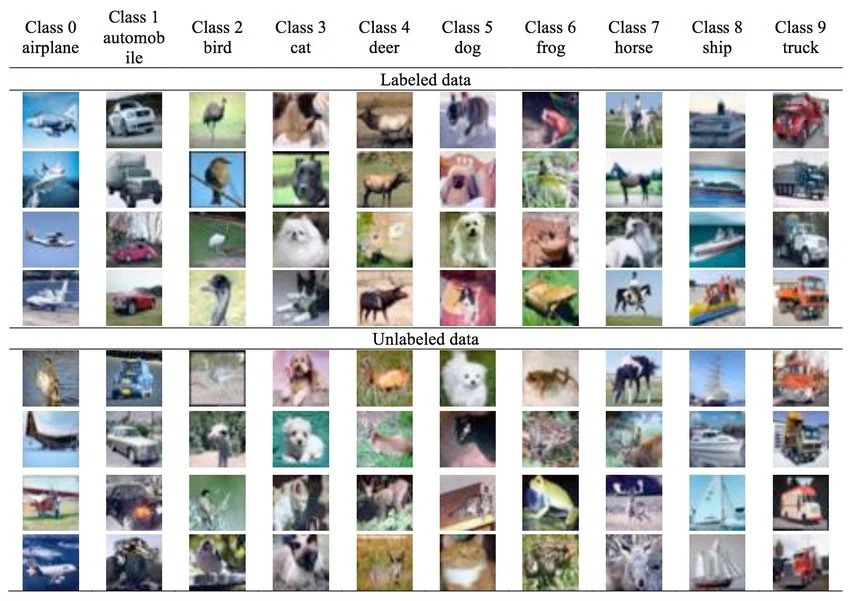

![alt text](RGB-arrays-combined-to-make-image.jpg)

![alt text](1_8zHs6CWVv_ljVQEEZ71fNQ.png)

![alt text](color-channels-RGB.jpg)

In [16]:
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

c:\Users\Jagdish singh\jupyter311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3), Testing labels shape: (10000, 1)


In [17]:
# 10 classes
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("Label names:", label_names)

Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [18]:
print(X_train.shape)  # 3 represent RGB
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


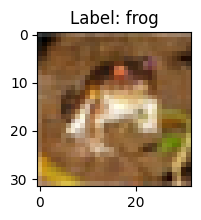

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[0])
plt.title(f"Label: {label_names[y_train[0][0]]}")
plt.show()

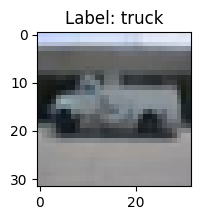

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[110])
plt.title(f"Label: {label_names[y_train[110][0]]}")
plt.show()

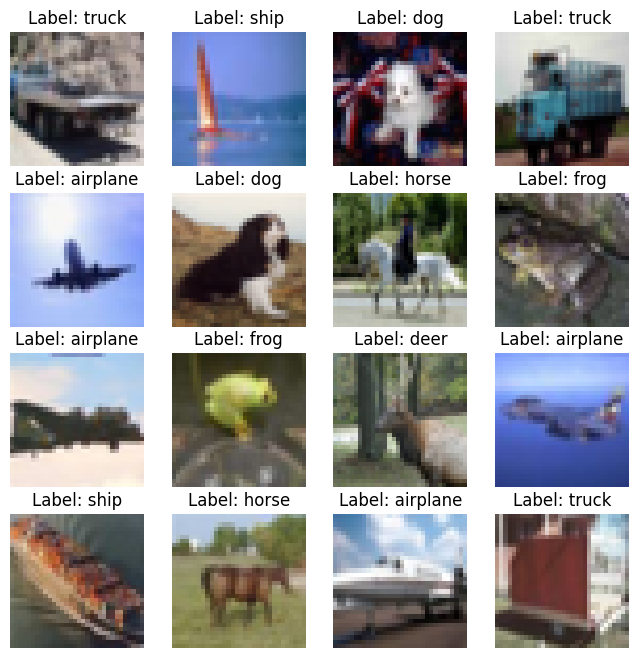

In [21]:

import random
import matplotlib.pyplot as plt

# Randomly select 16 images from the training set
selected_indices = random.sample(range(len(X_train)), 16)

# Create a grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

# Plot each selected image with its label
for i, idx in enumerate(selected_indices):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(f"Label: {label_names[y_train[idx][0]]}")
    axes[row, col].axis("off")

plt.show()

In [22]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], shape=(50000, 1), dtype=uint8)

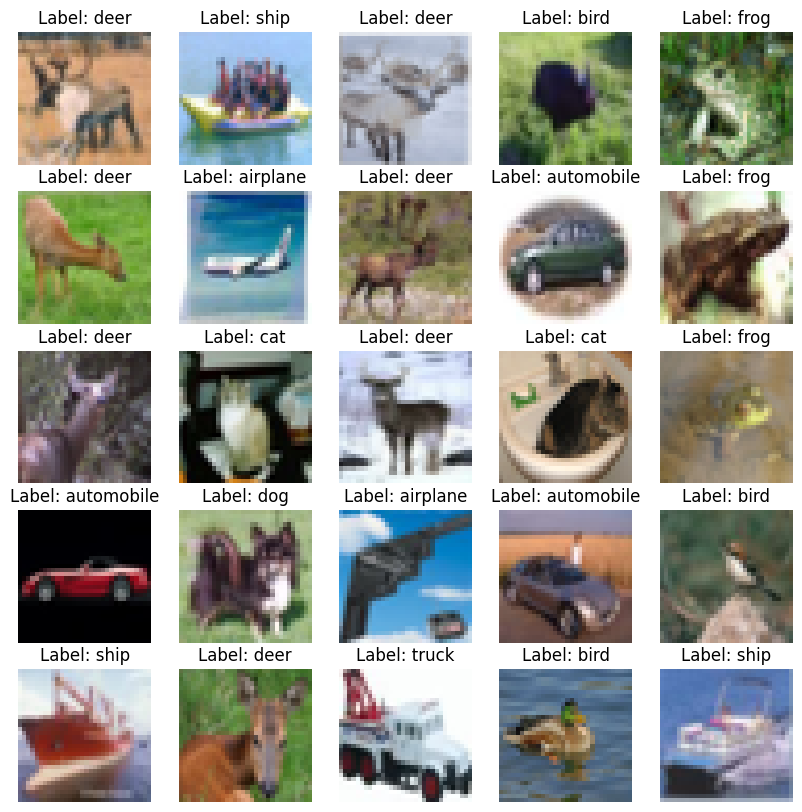

In [23]:
import random
plt.figure(figsize=(10,10))
for i in range(25):
    index = random.randint(0, len(X_train)-1)
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[index], cmap='gray')
    plt.title(f"Label: {label_names[y_train[index][0]]}")
    plt.axis('off')
plt.show()

In [24]:
y_train.shape

(50000, 1)

In [25]:
# CNN o/p will be 1d

In [26]:
#  targets are 2D array N x 1 instead of N.
# Therefore, we flatten them.
y_train, y_test = y_train.flatten(), y_test.flatten()
print(y_train.shape)
print(y_test.shape)

(50000,)
(10000,)


In [27]:
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [28]:
# $[0, 1]$ or $[-1, 1]$
X_train = X_train / 255.0
X_test = X_test / 255.0

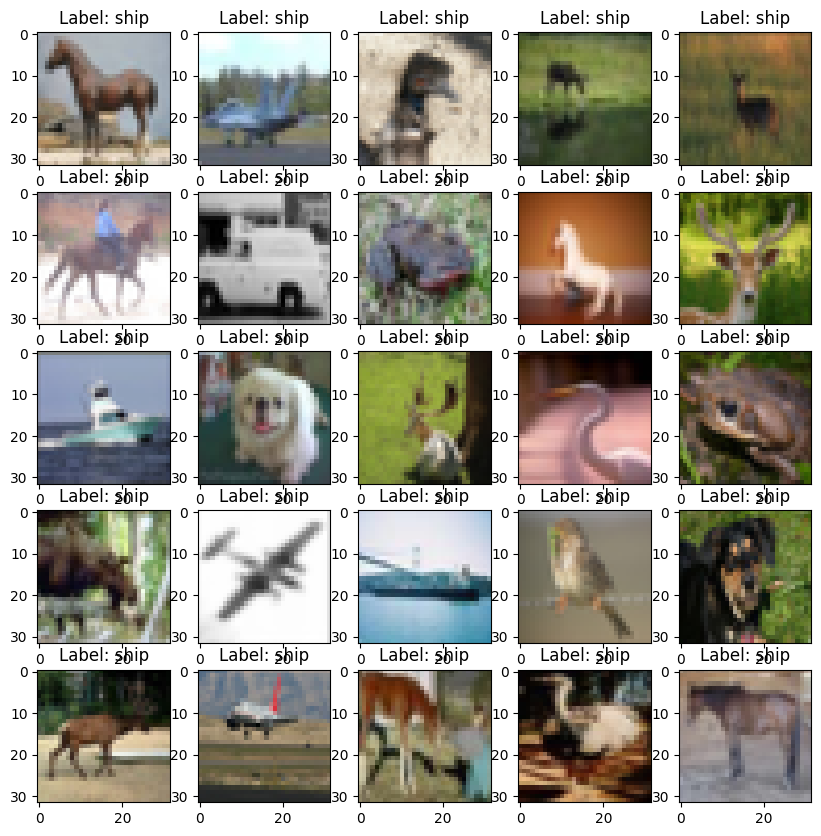

In [29]:
import random
import numpy as np
plt.figure(figsize=(10,10))
for i in range(25):
    indexs=np.random.randint(0,len(X_train))
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[indexs])
    #plt.title(f'label=y_train[indexs]')
    plt.title(f"Label: {label_names[y_train[index]]}")
plt.show()
    

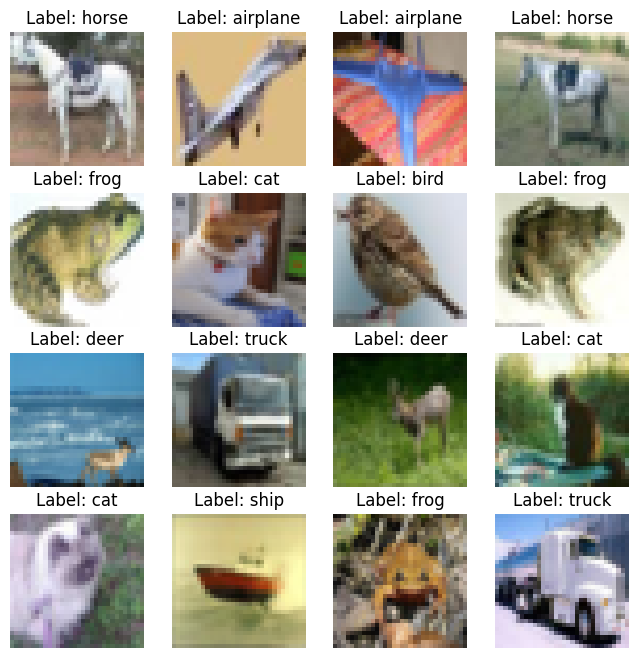

In [30]:
# Lets plot a grid of 4x4 images from the training set along with their labels in the title - randomly select 16 images from the training set
import random
import matplotlib.pyplot as plt

# Randomly select 16 images from the training set
selected_indices = random.sample(range(len(X_train)), 16)

# Create a grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
# Plot each selected image with its label
for i, idx in enumerate(selected_indices):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(f"Label: {label_names[y_train[idx]]}")
    axes[row, col].axis("off")
plt.show()

In [31]:
# ANN model for image classification

# from tensorflow.keras import Sequential
# from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

# model = Sequential()
# model.add(Input(shape=(32, 32, 3)))
# model.add(Flatten())

# model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(10, activation='softmax'))

In [32]:
'''
Conv2D → extracts image features
MaxPooling2D → reduces image size
Flatten → converts 2D feature maps → 1D vector
Dense → fully connected neural network
Dropout → prevents overfitting
Input → defines input shape
'''

'\nConv2D → extracts image features\nMaxPooling2D → reduces image size\nFlatten → converts 2D feature maps → 1D vector\nDense → fully connected neural network\nDropout → prevents overfitting\nInput → defines input shape\n'

In [33]:
# earlier we make a simple ANN model only on a colour image dataset

In [34]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))  # 32 filters detect edges & textures
model.add(MaxPooling2D((2, 2)))  # 3×3 kernel scans image  # Pooling reduces size by half
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))


#we cannot apply any further pooling ..otherwise image size < kernel size(3,3)
# 32*32 intitally --> 16*16 after first pooling --> 8*8 after 2nd pooling --> 4*4


model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [35]:
# If you find the model is training slowly or overfitting, try adding Batch Normalization:
# model.add(BatchNormalization())

In [36]:
32*32*3

3072

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659,594 (2.52 MB)

 Trainable params: 659,594 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [39]:
# Train the model
r = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.2814 - loss: 1.8579 - val_accuracy: 0.4706 - val_loss: 1.4370
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.4748 - loss: 1.4418 - val_accuracy: 0.5556 - val_loss: 1.2632
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5584 - loss: 1.2617 - val_accuracy: 0.6256 - val_loss: 1.0634
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.6146 - loss: 1.1263 - val_accuracy: 0.6360 - val_loss: 1.0611
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.6478 - loss: 1.0394 - val_accuracy: 0.6490 - val_loss: 1.0248
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6802 - loss: 0.9552 - val_accuracy: 0.7023 - val_loss: 0.8868
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.6972 - loss: 0.9072 - val_accuracy: 0.6949 - val_loss: 0.9117
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.7195 - loss: 0.8500 - 

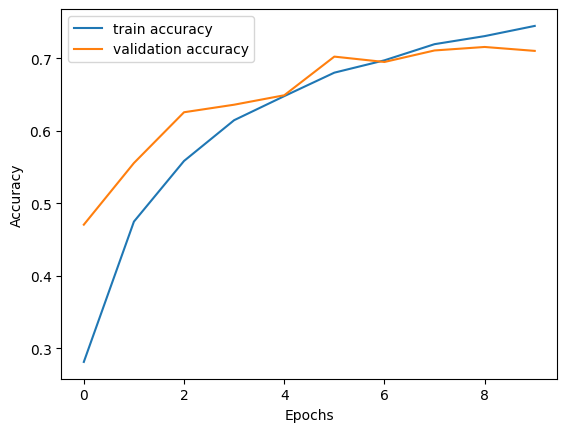

In [40]:
# Plot the accuracy and validation accuracy per epoch
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

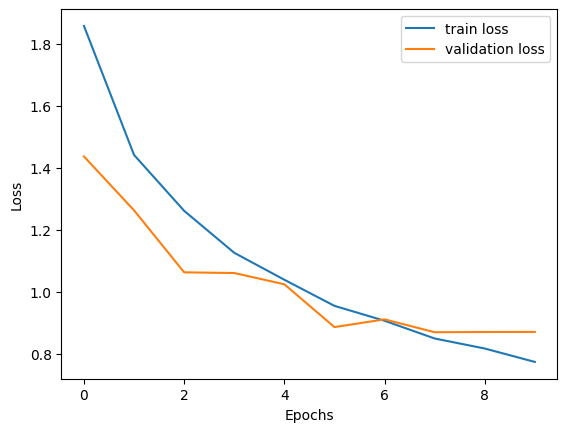

In [41]:
# Plot the loss and validation loss per epoch
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [42]:
import numpy as np
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


array([3, 8, 8, ..., 5, 1, 7], shape=(10000,))

In [43]:
y_pred.shape

(10000,)

In [44]:
y_test.shape

(10000,)

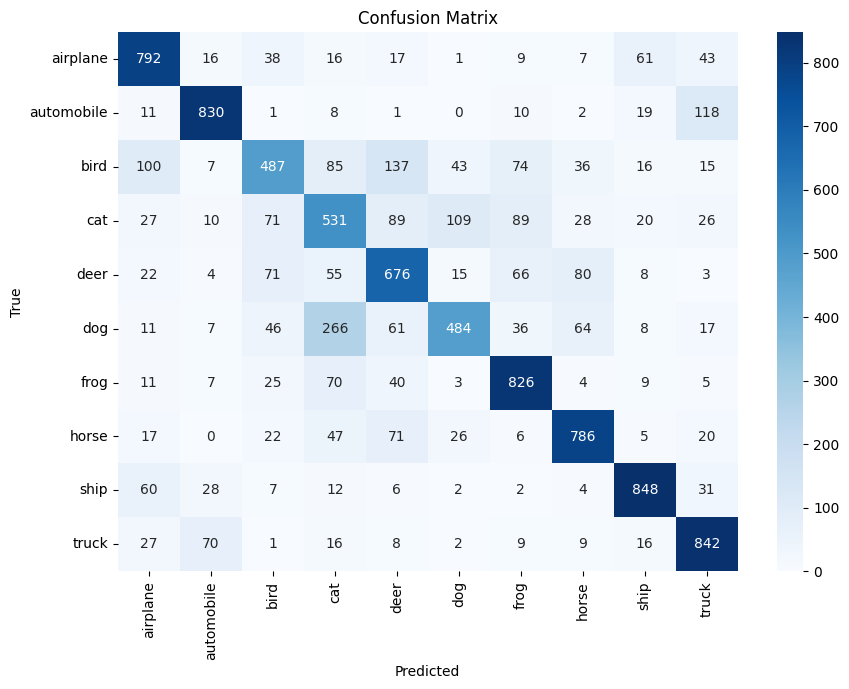

In [45]:
# Lets look at the confusion matrix with True labels on x-axis and Predicted labels on y-axis
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [46]:
cm

array([[792,  16,  38,  16,  17,   1,   9,   7,  61,  43],
       [ 11, 830,   1,   8,   1,   0,  10,   2,  19, 118],
       [100,   7, 487,  85, 137,  43,  74,  36,  16,  15],
       [ 27,  10,  71, 531,  89, 109,  89,  28,  20,  26],
       [ 22,   4,  71,  55, 676,  15,  66,  80,   8,   3],
       [ 11,   7,  46, 266,  61, 484,  36,  64,   8,  17],
       [ 11,   7,  25,  70,  40,   3, 826,   4,   9,   5],
       [ 17,   0,  22,  47,  71,  26,   6, 786,   5,  20],
       [ 60,  28,   7,  12,   6,   2,   2,   4, 848,  31],
       [ 27,  70,   1,  16,   8,   2,   9,   9,  16, 842]])

In [47]:
misclassified_indices = np.where(y_test != y_pred)[0]
misclassified_indices

array([  12,   17,   22, ..., 9993, 9995, 9996], shape=(2898,))

In [48]:

misclassified_indices = np.where(y_test.flatten() != y_pred)[0]
misclassified_indices

array([  12,   17,   22, ..., 9993, 9995, 9996], shape=(2898,))

In [49]:

print(f'Total misclassified images: {len(misclassified_indices)}')

Total misclassified images: 2898


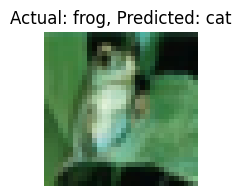

In [50]:
import random

random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

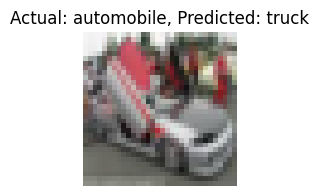

In [51]:
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

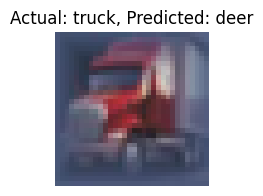

In [52]:

random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

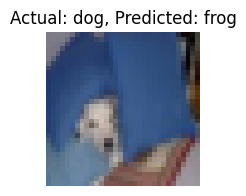

In [53]:

random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.2551 - loss: 1.9341 - val_accuracy: 0.4184 - val_loss: 1.5501
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.4340 - loss: 1.5486 - val_accuracy: 0.5232 - val_loss: 1.3371
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5202 - loss: 1.3580 - val_accuracy: 0.5681 - val_loss: 1.2101
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5681 - loss: 1.2366 - val_accuracy: 0.6086 - val_loss: 1.1204
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6035 - loss: 1.1527 - val_accuracy: 0.6186 - val_loss: 1.0634
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.6324 - loss: 1.0763 - val_accuracy: 0.6368 - val_loss: 1.0675
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6555 - loss: 1.0084 - val_accuracy: 0.6445 - val_loss: 1.0296
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6756 - loss: 0.9530 - 

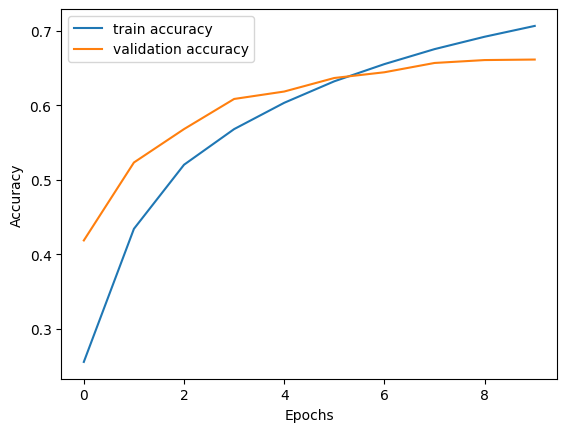

In [54]:
model = Sequential()
model.add(Input(shape=(32, 32, 3)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', strides=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', strides=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same', strides=(2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))
 
 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
r = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=64)

plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 45ms/step - accuracy: 0.3214 - loss: 1.8735 - val_accuracy: 0.4714 - val_loss: 1.4359
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.4826 - loss: 1.4539 - val_accuracy: 0.5574 - val_loss: 1.2320
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.5532 - loss: 1.2795 - val_accuracy: 0.5384 - val_loss: 1.3268
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.6039 - loss: 1.1502 - val_accuracy: 0.5085 - val_loss: 1.5323
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6429 - loss: 1.0504 - val_accuracy: 0.6566 - val_loss: 0.9595
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6716 - loss: 0.9749 - val_accuracy: 0.6289 - val_loss: 1.0858
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6961 - loss: 0.9041 - val_accuracy: 0.6923 - val_loss: 0.9093
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.7170 - loss: 0.8504 - 

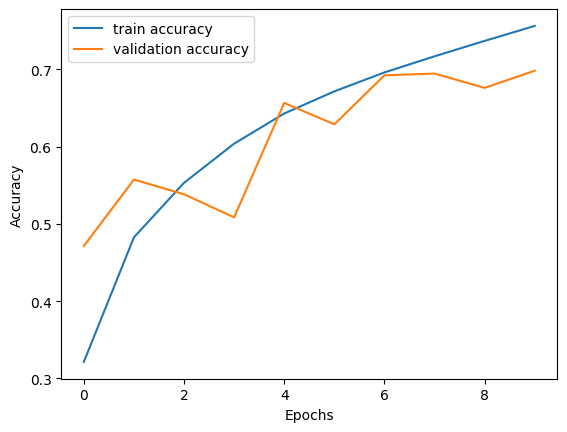

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()
model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(32, (3, 3), padding='same', strides=(2, 2)))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))

model.add(Conv2D(64, (3, 3), padding='same', strides=(2, 2)))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))

model.add(Conv2D(128, (3, 3), padding='same', strides=(2, 2)))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))

model.add(Flatten())

model.add(Dense(256))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(64))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

r = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=64)

plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.2691 - loss: 2.0112 - val_accuracy: 0.1000 - val_loss: 3.2224
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.4082 - loss: 1.6420 - val_accuracy: 0.1000 - val_loss: 44.0019
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - accuracy: 0.4653 - loss: 1.5115 - val_accuracy: 0.1000 - val_loss: 34.7797
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.5015 - loss: 1.4249 - val_accuracy: 0.1010 - val_loss: 3.8521
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.5252 - loss: 1.3674 - val_accuracy: 0.1166 - val_loss: 6.9494
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 116ms/step - accuracy: 0.5454 - loss: 1.3189 - val_accuracy: 0.1000 - val_loss: 20.6850
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.5621 - loss: 1.2745 - val_accuracy: 0.1000 - val_loss: 16.0622
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 81ms/step - accuracy: 0.5769 - loss: 1.2

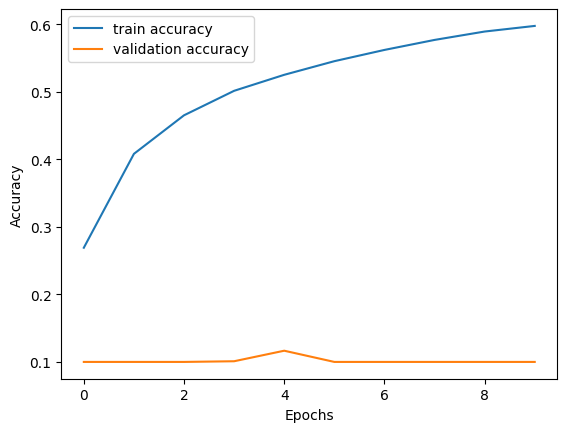

In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow(X_train, y_train, batch_size=64)
test_generator = test_datagen.flow(X_test, y_test, batch_size=64)

model = Sequential()
model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(32, (3, 3), padding='same', strides=(2, 2)))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))

model.add(Conv2D(64, (3, 3), padding='same', strides=(2, 2)))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))

model.add(Conv2D(128, (3, 3), padding='same', strides=(2, 2)))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))

model.add(Flatten())

model.add(Dense(256))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(64))
model.add(BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

r = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()